# 딥러닝 기초 1일차 실습과제: 퍼셉트론과 활성화 함수

## 과제 개요
신경망의 기본 단위인 퍼셉트론을 구현하고, 대표적인 활성화 함수(Sigmoid, ReLU, Tanh, Leaky ReLU)의 특성을 비교한다.

### 학습 목표
1. 퍼셉트론의 구조와 원리 이해
2. 논리 게이트(AND, OR, NAND, XOR) 구현
3. 다층 퍼셉트론의 필요성 이해
4. 활성화 함수(Sigmoid, ReLU, Tanh) 비교


## Part 0: 환경 설정

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

print("환경 설정 완료!")


환경 설정 완료!


## Part 1: 퍼셉트론 기초

### 퍼셉트론이란?
- 입력값에 가중치를 곱하고 편향을 더한 후, 활성화 함수를 적용하는 가장 단순한 신경망 단위
- 수식: $y = f(w_1 x_1 + w_2 x_2 + b)$

### 논리 게이트 진리표
| $x_1$ | $x_2$ | AND | OR | NAND | XOR |
|:-----:|:-----:|:---:|:--:|:----:|:---:|
| 0 | 0 | 0 | 0 | 1 | 0 |
| 0 | 1 | 0 | 1 | 1 | 1 |
| 1 | 0 | 0 | 1 | 1 | 1 |
| 1 | 1 | 1 | 1 | 0 | 0 |


In [2]:
def step_function(x):
    """계단 함수: 0보다 크면 1, 아니면 0"""
    return 1 if x > 0 else 0

def perceptron(x1, x2, w1, w2, b):
    """퍼셉트론 연산: 가중합을 구하고 계단 함수를 적용한다"""
    z = w1 * x1 + w2 * x2 + b
    return step_function(z)

def and_gate(x1, x2):
    w1, w2, b = 0.5, 0.5, -0.7
    return perceptron(x1, x2, w1, w2, b)

def or_gate(x1, x2):
    w1, w2, b = 0.5, 0.5, -0.3
    return perceptron(x1, x2, w1, w2, b)

print("AND 게이트 테스트:")
for x1, x2 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    print(f"  AND({x1}, {x2}) = {and_gate(x1, x2)}")

print("\nOR 게이트 테스트:")
for x1, x2 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    print(f"  OR({x1}, {x2}) = {or_gate(x1, x2)}")


AND 게이트 테스트:
  AND(0, 0) = 0
  AND(0, 1) = 0
  AND(1, 0) = 0
  AND(1, 1) = 1

OR 게이트 테스트:
  OR(0, 0) = 0
  OR(0, 1) = 1
  OR(1, 0) = 1
  OR(1, 1) = 1


### [필수] 과제 1-1: NAND 게이트 구현하기

NAND는 AND의 결과를 뒤집은 게이트다. AND 게이트의 가중치/편향 부호를 모두 반대로 바꾸면 얻을 수 있다.

In [3]:
def nand_gate(x1, x2):
    w1 = -0.5
    w2 = -0.5
    b = 0.7
    return perceptron(x1, x2, w1, w2, b)

print("NAND 게이트 테스트:")
print("기대값: NAND(0,0)=1, NAND(0,1)=1, NAND(1,0)=1, NAND(1,1)=0")
print()
for x1, x2 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    result = nand_gate(x1, x2)
    print(f"  NAND({x1}, {x2}) = {result}")


NAND 게이트 테스트:
기대값: NAND(0,0)=1, NAND(0,1)=1, NAND(1,0)=1, NAND(1,1)=0

  NAND(0, 0) = 1
  NAND(0, 1) = 1
  NAND(1, 0) = 1
  NAND(1, 1) = 0


## Part 2: XOR 문제와 다층 퍼셉트론

XOR은 단일 퍼셉트론으로 구현할 수 없다.
- XOR: 입력이 서로 다를 때 1, 같을 때 0
- 단일 퍼셉트론은 하나의 직선으로만 분류 가능(선형 분리)
- XOR은 직선 하나로 분류할 수 없음 -> 다층 퍼셉트론(MLP) 필요


In [4]:
# XOR = AND(NAND(x1, x2), OR(x1, x2))
def xor_gate(x1, x2):
    """
    XOR 게이트 - 2층 퍼셉트론으로 구현
    은닉층: NAND(x1,x2), OR(x1,x2)
    출력층: AND(은닉1, 은닉2)
    """
    s1 = nand_gate(x1, x2)
    s2 = or_gate(x1, x2)
    y = and_gate(s1, s2)
    return y

print("XOR 게이트 테스트 (다층 퍼셉트론):")
print("기대값: XOR(0,0)=0, XOR(0,1)=1, XOR(1,0)=1, XOR(1,1)=0")
print()
for x1, x2 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    result = xor_gate(x1, x2)
    print(f"  XOR({x1}, {x2}) = {result}")

print("\n=> 여러 퍼셉트론을 쌓으면 비선형 문제도 해결할 수 있다.")
print("   이것이 다층 퍼셉트론(MLP)의 핵심 아이디어다.")


XOR 게이트 테스트 (다층 퍼셉트론):
기대값: XOR(0,0)=0, XOR(0,1)=1, XOR(1,0)=1, XOR(1,1)=0

  XOR(0, 0) = 0
  XOR(0, 1) = 1
  XOR(1, 0) = 1
  XOR(1, 1) = 0

=> 여러 퍼셉트론을 쌓으면 비선형 문제도 해결할 수 있다.
   이것이 다층 퍼셉트론(MLP)의 핵심 아이디어다.


### [필수] 과제 2-1: 퍼셉트론 이해도 점검

1. 퍼셉트론에서 **가중치(weight)**의 역할은 무엇인가요?
   - 답변: 가중치는 각 입력이 출력에 얼마나 영향을 미치는지를 결정하는 값이다. 가중치가 클수록 해당 입력이 가중합(z)에 더 크게 기여하며, 학습 과정에서 이 가중치를 조정함으로써 퍼셉트론이 원하는 판단 경계(직선)를 찾아가게 된다.

2. 단일 퍼셉트론으로 XOR을 구현할 수 없는 이유는?
   - 답변: 단일 퍼셉트론은 입력 공간을 하나의 직선(선형 결정 경계)으로만 나눌 수 있는데, XOR의 참(1)인 두 점 (0,1),(1,0)과 거짓(0)인 두 점 (0,0),(1,1)은 어떤 직선 하나로도 분리할 수 없는 배치이기 때문이다. 이를 해결하려면 여러 퍼셉트론을 층으로 쌓아 비선형 경계를 만들어야 한다.

## Part 3: 활성화 함수 비교

활성화 함수는 신경망에 비선형성을 부여한다.

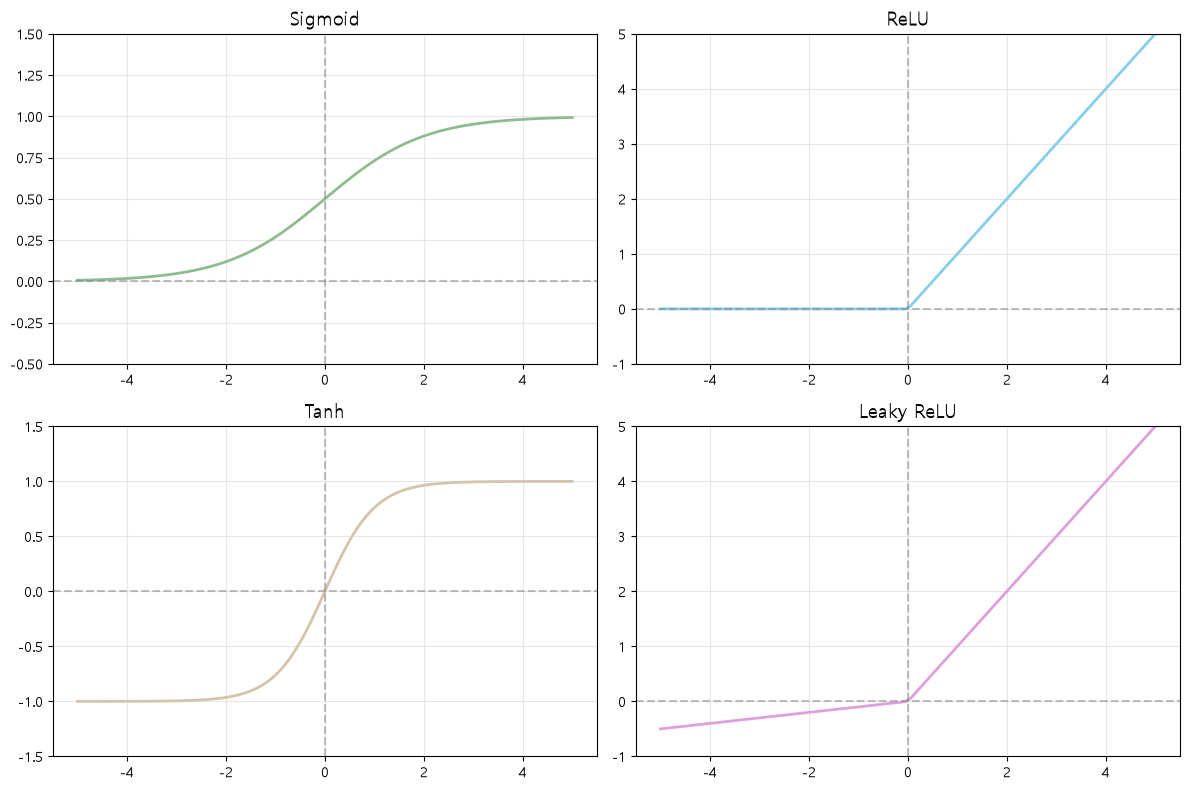

In [5]:
def sigmoid(x):
    """Sigmoid: 출력을 0~1 사이로 압축"""
    return 1 / (1 + np.exp(-x))

def relu(x):
    """ReLU: 음수는 0, 양수는 그대로"""
    return np.maximum(0, x)

def tanh(x):
    """Tanh: 출력을 -1~1 사이로 압축"""
    return np.tanh(x)

def leaky_relu(x, alpha=0.1):
    """Leaky ReLU: 음수에도 작은 기울기 부여"""
    return np.where(x > 0, x, alpha * x)

x = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(x, sigmoid(x), color='#8FBC8F', linewidth=2)
axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Sigmoid', fontsize=14)
axes[0, 0].set_ylim(-0.5, 1.5)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x, relu(x), color='#87CEEB', linewidth=2)
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_title('ReLU', fontsize=14)
axes[0, 1].set_ylim(-1, 5)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(x, tanh(x), color='#D4C4A8', linewidth=2)
axes[1, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Tanh', fontsize=14)
axes[1, 0].set_ylim(-1.5, 1.5)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(x, leaky_relu(x), color='#DDA0DD', linewidth=2)
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Leaky ReLU', fontsize=14)
axes[1, 1].set_ylim(-1, 5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
print("=" * 70)
print("활성화 함수 특성 비교")
print("=" * 70)
print(f"{'함수':<12} {'출력 범위':<15} {'장점':<25} {'단점'}")
print("-" * 70)
print(f"{'Sigmoid':<12} {'0 ~ 1':<15} {'확률 해석 가능':<25} {'기울기 소실'}")
print(f"{'ReLU':<12} {'0 ~ inf':<15} {'빠른 학습, 간단':<25} {'Dying ReLU'}")
print(f"{'Tanh':<12} {'-1 ~ 1':<15} {'0 중심':<25} {'기울기 소실'}")
print(f"{'Leaky ReLU':<12} {'-inf ~ inf':<15} {'Dying ReLU 해결':<25} {'alpha 튜닝 필요'}")
print("=" * 70)


활성화 함수 특성 비교
함수           출력 범위           장점                        단점
----------------------------------------------------------------------
Sigmoid      0 ~ 1           확률 해석 가능                  기울기 소실
ReLU         0 ~ inf         빠른 학습, 간단                 Dying ReLU
Tanh         -1 ~ 1          0 중심                      기울기 소실
Leaky ReLU   -inf ~ inf      Dying ReLU 해결             alpha 튜닝 필요


### [필수] 과제 3-1: 활성화 함수 이해도 점검

1. 은닉층에서 ReLU가 Sigmoid보다 많이 사용되는 이유는?
   - 답변: Sigmoid는 입력이 큰 양수나 큰 음수일 때 기울기가 0에 매우 가까워져서, 층이 깊어질수록 역전파 과정에서 기울기가 점점 작아지다 사라지는 기울기 소실 문제가 심하다. 반면 ReLU는 양수 구간에서 기울기가 항상 1이라 신호가 잘 전달되고, 연산도 max(0, x) 하나뿐이라 계산 비용이 훨씬 저렴해 깊은 신경망 학습에 유리하다.

2. 이진 분류 문제의 출력층에서 어떤 활성화 함수를 사용해야 하나요? 그 이유는?
   - 답변: Sigmoid를 사용한다. Sigmoid의 출력이 0~1 범위이기 때문에 이를 '양성 클래스일 확률'로 해석할 수 있고, 보통 0.5를 기준으로 임계값을 나눠 최종 클래스를 결정한다. 이 확률 해석이 가능하다는 성질 때문에 손실 함수로 Binary Cross Entropy와 함께 자연스럽게 짝을 이뤄 사용된다.

## Part 4: [도전] Softmax 함수 구현

다중 클래스 분류에서 사용하는 Softmax 함수를 구현한다.
softmax(x_i) = exp(x_i) / sum(exp(x_j))

In [7]:
def softmax(x):
    """
    Softmax 함수: 입력을 확률 분포로 변환
    - 모든 출력은 0~1 사이
    - 모든 출력의 합은 1
    - 다중 클래스 분류의 출력층에서 사용
    """
    shifted_x = x - np.max(x)  # 오버플로 방지
    exp_x = np.exp(shifted_x)
    return exp_x / np.sum(exp_x)

test_input = np.array([2.0, 1.0, 0.1])
result = softmax(test_input)

print(f"입력: {test_input}")
print(f"Softmax 출력: {result}")
print(f"합계: {np.sum(result):.4f} (1이 되어야 함)")


입력: [2.  1.  0.1]
Softmax 출력: [0.65900114 0.24243297 0.09856589]
합계: 1.0000 (1이 되어야 함)


## 오늘의 회고

퍼셉트론 자체는 단순한 가중합 + 계단함수인데, 이것만으로 AND/OR/NAND 같은 선형 분리 가능한 문제는 다 풀리고
XOR처럼 선형으로 못 가르는 문제는 아예 풀 수 없다는 게 인상적이었다. NAND와 OR를 은닉층으로 두고 그 위에
AND를 하나 더 얹으면 XOR이 풀린다는 걸 직접 코드로 확인하니, "층을 쌓는다"는 말이 왜 신경망의 표현력을 늘려주는지
감이 잡혔다. 활성화 함수 파트에서는 Sigmoid/Tanh는 극단값에서 그래프가 평평해지는 게(기울기 소실) 눈으로 바로
보였고, ReLU가 왜 요즘 은닉층 기본값처럼 쓰이는지도 그래프 개형만 보고 이해가 됐다.